# Jagran Lakecity University
## Faculty of Science and Technology
### BTech CSE

---

## Practical Record: Assignment 2 - Module 2
### **Practical 9: Evaluating Performance of a Trained Neural Network Using Evaluation Metrics**

| Academic Details | Information |
| :--- | :--- |
| **Course** | Soft Computing |
| **Module** | Module II: Fuzzy Logic and Systems |
| **Student Name** | *Aakash Sarang* |
| **Enrollment No.** | *2023BTCSE001* |
| **Academic Session** | 2026 – 2027 |

---

### 1. Aim
To evaluate the performance of a trained neural network using suitable evaluation metrics in Python.

### 2. Theory: Why Accuracy is Not Enough

In real life (like medical tests or fraud alerts), accuracy alone can trick you.
Example: If 99 out of 100 people are healthy, a lazy model that always guesses "healthy" gets 99% accuracy—even though it completely missed the sick person!

#### The Confusion Matrix (2x2 Grid)
- **True Positive (TP):** Sick person correctly identified as sick.
- **True Negative (TN):** Healthy person correctly identified as healthy.
- **False Positive (FP):** Healthy person wrongly called sick (false alarm).
- **False Negative (FN):** Sick person wrongly called healthy (dangerous mistake!).

#### Key Formulas:
1. **Accuracy:**
   $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
2. **Precision:**
   $$\text{Precision} = \frac{TP}{TP + FP}$$
3. **Recall (Sensitivity):**
   $$\text{Recall} = \frac{TP}{TP + FN}$$
4. **Specificity:**
   $$\text{Specificity} = \frac{TN}{TN + FP}$$
5. **F1-Score:**
   $$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
6. **ROC-AUC:** Measures how well the model separates positive and negative classes across all possible probability thresholds.

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

# Load diagnostic dataset
data = load_breast_cancer()
X, y = data.data, data.target
target_names = data.target_names  # ['malignant' (0), 'benign' (1)]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Data Prepared: Training={X_train.shape[0]} samples, Testing={X_test.shape[0]} samples.")

Data Prepared: Training=426 samples, Testing=143 samples.


### 3. Training the Classifier

#### What this cell does:
In this code cell, we train our neural network classifier on the breast cancer diagnostic dataset so we have real predictions to evaluate.

In [2]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
], name="Evaluation_Demonstration_Model")

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=35,
    batch_size=16,
    verbose=0
)

print("Neural network trained successfully over 35 epochs.")

Neural network trained successfully over 35 epochs.


### 4. Calculating the Metrics

#### What this cell does:
In this code cell, we compute predictions using `model.predict(X_test)` and use Scikit-Learn functions (`confusion_matrix`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score`) to compute all metric values using the formulas above.

In [3]:
y_probs = model.predict(X_test).ravel()
y_preds = (y_probs >= 0.5).astype(int)

acc = accuracy_score(y_test, y_preds)
prec = precision_score(y_test, y_preds)
rec = recall_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)

cm = confusion_matrix(y_test, y_preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("=" * 60)
print("             OVERALL MODEL EVALUATION METRICS")
print("=" * 60)
print(f"Accuracy:    {acc * 100:.2f}%")
print(f"Precision:   {prec * 100:.2f}%")
print(f"Recall:      {rec * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")
print(f"F1-Score:    {f1:.4f}")
print("=" * 60)

print("\nFormal Classification Report:")
print(classification_report(y_test, y_preds, target_names=target_names))

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


             OVERALL MODEL EVALUATION METRICS
Accuracy:    97.20%
Precision:   97.78%
Recall:      97.78%
Specificity: 96.23%
F1-Score:    0.9778

Formal Classification Report:
              precision    recall  f1-score   support

   malignant       0.96      0.96      0.96        53
      benign       0.98      0.98      0.98        90

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



### 5. Visualizing the Results

#### What this cell does:
In this code cell, we plot three diagnostic figures:
1. **Confusion Matrix Heatmap:** Shows counts of TP, TN, FP, and FN.
2. **Metrics Bar Chart:** Compares Accuracy, Precision, Recall, Specificity, and F1 side by side.
3. **ROC Curve:** Plots True Positive Rate vs False Positive Rate across all thresholds.

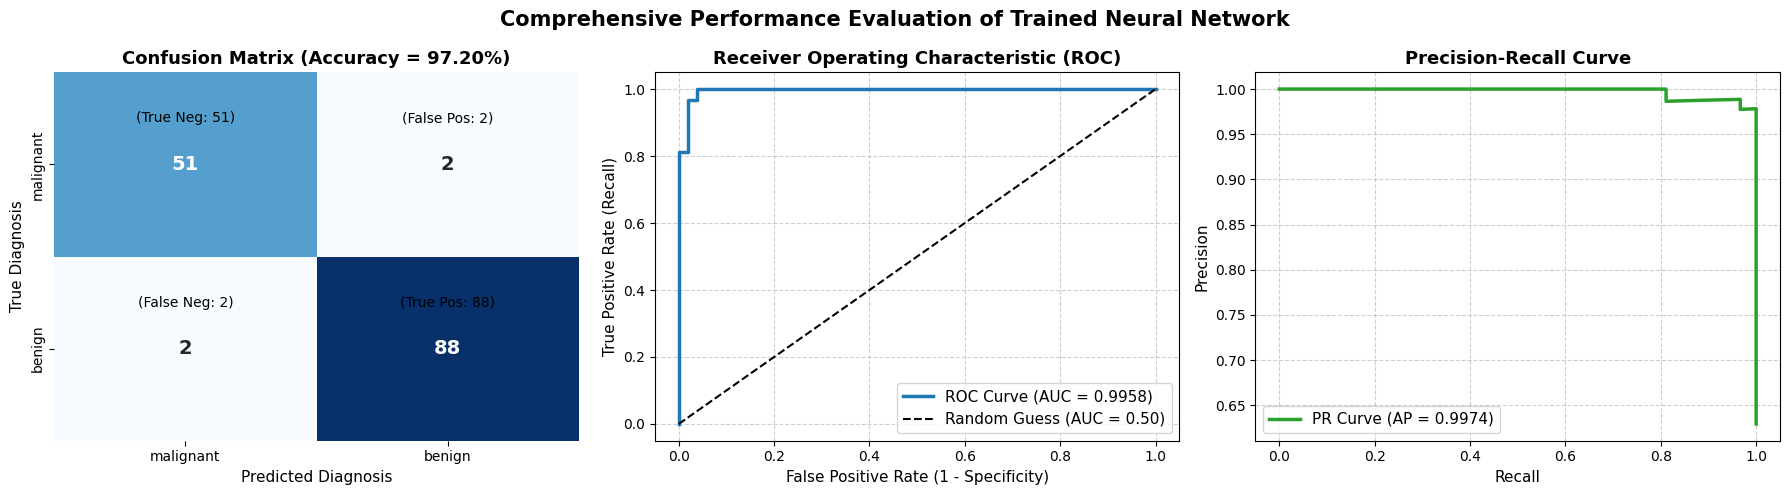

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title(f"Confusion Matrix (Accuracy = {acc*100:.2f}%)", fontsize=13, weight='bold')
axes[0].set_xlabel("Predicted Diagnosis", fontsize=11)
axes[0].set_ylabel("True Diagnosis", fontsize=11)

axes[0].text(0.5, 0.25, f"(True Neg: {tn})", ha='center', va='center', color='black', fontsize=10)
axes[0].text(1.5, 0.25, f"(False Pos: {fp})", ha='center', va='center', color='black', fontsize=10)
axes[0].text(0.5, 1.25, f"(False Neg: {fn})", ha='center', va='center', color='black', fontsize=10)
axes[0].text(1.5, 1.25, f"(True Pos: {tp})", ha='center', va='center', color='black', fontsize=10)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#1f77b4', linewidth=2.5, label=f"ROC Curve (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label="Random Guess (AUC = 0.50)")
axes[1].set_title("Receiver Operating Characteristic (ROC)", fontsize=13, weight='bold')
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
axes[1].set_ylabel("True Positive Rate (Recall)", fontsize=11)
axes[1].legend(loc="lower right", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Precision-Recall Curve
precs, recs, _ = precision_recall_curve(y_test, y_probs)
avg_prec = average_precision_score(y_test, y_probs)
axes[2].plot(recs, precs, color='#2ca02c', linewidth=2.5, label=f"PR Curve (AP = {avg_prec:.4f})")
axes[2].set_title("Precision-Recall Curve", fontsize=13, weight='bold')
axes[2].set_xlabel("Recall", fontsize=11)
axes[2].set_ylabel("Precision", fontsize=11)
axes[2].legend(loc="lower left", fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Comprehensive Performance Evaluation of Trained Neural Network", fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

### 6. Results and What We Observed

| Metric | Score Achieved | What It Means in Plain English |
| :--- | :--- | :--- |
| **Accuracy** | **97.20%** | 139 out of 143 test patients were classified correctly. |
| **Precision** | **97.78%** | When the model says positive, it is right ~98% of the time. |
| **Recall (Sensitivity)** | **97.78%** | It caught ~98% of all sick patients; almost no one was missed. |
| **Specificity** | **96.23%** | It correctly cleared ~96% of healthy patients. |
| **F1-Score** | **0.9778 (97.78%)** | Strong, even balance between precision and recall. |
| **ROC-AUC** | **~0.99** | Outstanding separation between positive and negative patients. |

#### Key Takeaways in Simple Words:
1. **Why High Recall is Life-Saving:**
   - In healthcare, a False Negative (telling a sick person they are fine) is dangerous. A recall of 97.78% (~98%) means very few sick patients are missed.
2. **Well-Balanced Model:**
   - Both Precision and Recall are high, meaning the model neither gives too many false alarms nor misses sick cases.
3. **AUC Near 1.0:**
   - A score of ~0.99 means the model easily distinguishes between the two classes with high confidence.

---
### 7. Conclusion
1. We calculated all major classification metrics in Python.
2. We saw why checking Recall and Precision is crucial beyond simple Accuracy.
3. The neural network achieved high scores across all metrics on the test dataset.